# Task 1

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

def set_seed(seed=2137):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

def get_device():
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = torch.device(get_device())

print(f"Device: {device}")

Device: mps


In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z
    
    def decode(self, z):
        logits = self.decoder(z)
        return logits
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar

In [5]:
def vae_loss(x_logits, x, mu, logvar):
    recon_loss = F.binary_cross_entropy_with_logits(x_logits, x, reduction="sum")

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + kl_loss

    return total_loss / x.size(0), recon_loss / x.size(0), kl_loss / x.size(0)

In [12]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

vae_model = VAE(latent_dim=20).to(device)
optimizer = optim.Adam(vae_model.parameters(), lr=1e-4)

In [ ]:
history_total, history_recon, history_kl = [], [], []

EPOCHS = 10

vae_model.train()
for epoch in range(EPOCHS): 
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device).view(-1, 28*28)
        optimizer.zero_grad()
        
        logits, mu, logvar = vae_model(data)
        loss, r_loss, k_loss = vae_loss(logits, data, mu, logvar)
        
        loss.backward()
        optimizer.step()
        
        history_total.append(loss.item())
        history_recon.append(r_loss.item())
        history_kl.append(k_loss.item())
    print(f"VAE Epoch {epoch+1}/{EPOCHS} | Total Loss: {loss.item():.2f}")

VAE Epoch 1/3 | Total Loss: 193.78
VAE Epoch 2/3 | Total Loss: 167.80
VAE Epoch 3/3 | Total Loss: 147.14
VAE Epoch 4/3 | Total Loss: 142.08
VAE Epoch 5/3 | Total Loss: 131.63
VAE Epoch 6/3 | Total Loss: 136.45
VAE Epoch 7/3 | Total Loss: 132.26
VAE Epoch 8/3 | Total Loss: 120.51
VAE Epoch 9/3 | Total Loss: 119.36
VAE Epoch 10/3 | Total Loss: 119.71


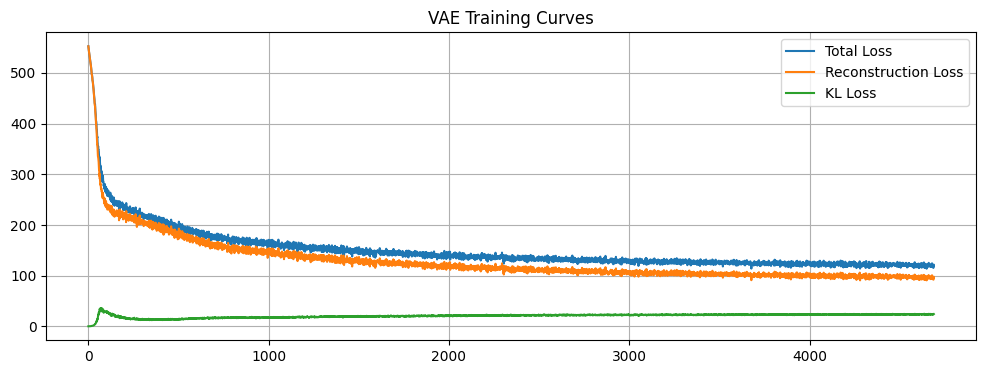

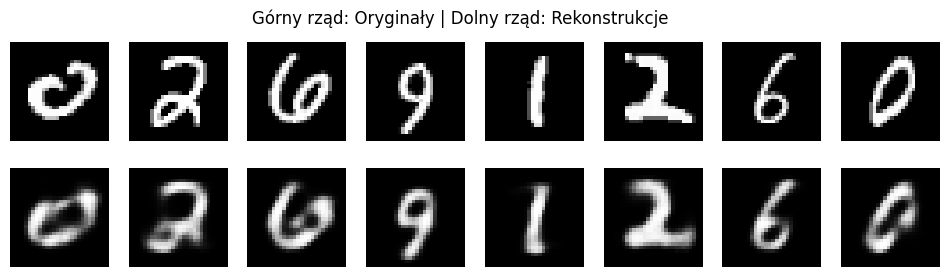

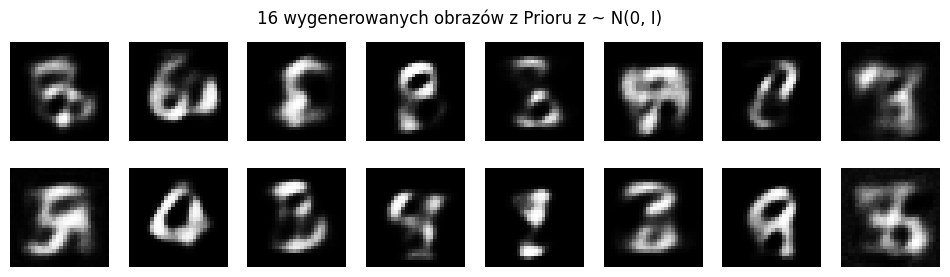

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(history_total, label='Total Loss')
plt.plot(history_recon, label='Reconstruction Loss')
plt.plot(history_kl, label='KL Loss')
plt.title('VAE Training Curves')
plt.legend(); plt.grid(True); plt.show()

# rekonstrukcje
vae_model.eval()
with torch.no_grad():
    test_data, _ = next(iter(train_loader))
    inputs = test_data[:8].to(device).view(-1, 784)
    logits, _, _ = vae_model(inputs)
    outputs = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(test_data[i].squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(outputs[i].squeeze(), cmap='gray'); axes[1, i].axis('off')
plt.suptitle("Górny rząd: Oryginały | Dolny rząd: Rekonstrukcje")
plt.show()

# generowanie nowych próbek
with torch.no_grad():
    z_samples = torch.randn(16, 20).to(device)
    gen_logits = vae_model.decode(z_samples)
    gen_images = torch.sigmoid(gen_logits).view(-1, 28, 28).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(gen_images[i], cmap='gray'); ax.axis('off')
plt.suptitle("16 wygenerowanych obrazów z Prioru z ~ N(0, I)")
plt.show()

KOMENTARZ

### VAE Discussion:
1. **Co zwraca enkoder:** Enkoder zwraca dwa wektory: $\mu$ (średnia) oraz $\log \sigma^2$ (logarytm wariancji), definiując diagonalny rozkład normalny reprezentacji ukrytej $q_\phi(z|x)$.
2. **Dlaczego akurat te parametry:** Bezpośrednie przewidywanie wariancji mogłoby prowadzić do ujemnych wartości. Przewidywanie $\log \sigma^2$ gwarantuje matematyczną poprawność $\sigma^2 = \exp(\text{logvar}) > 0$.
3. **Reparameterization Trick:** Próbkowanie bezpośrednie z $z \sim \mathcal{N}(\mu, \sigma^2)$ jest operacją stochastyczną, przez którą nie da się policzyć pochodnej (brak przepływu gradientu). Wyciągając szum na zewnątrz ($z = \mu + \sigma \odot \epsilon$, gdzie $\epsilon \sim \mathcal{N}(0, I)$), operacja stochastyczna staje się niezależnym liściem grafu obliczeniowego, co pozwala na backpropagation.
4. **Rola członu KL:** Komponent Dywergencji KL wymusza na enkoderze, by rozkładał zakodowane klastry blisko standardowego rozkładu normalnego $\mathcal{N}(0, I)$. Zapobiega to sytuacji, w której enkoder separuje klasy w nieskończoność (co zniszczyłoby zdolności generatywne).
5. **Próbkowanie z z ~ N(0,I):** Skoro człon KL podczas uczenia zmusza przestrzeń ukrytą do konwergencji w stronę $\mathcal{N}(0,I)$, to po zakończeniu treningu możemy legalnie losować próbki z tego rozkładu i dekodować je w nowe obrazy.
6. **Ostrość próbek:** Próbki są rozmyte. Wynika to z faktu, że funkcja straty oparta na MSE lub BCE wymusza uśrednianie wartości pikseli.

# Task 2

In [15]:
class VelocityNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Input features: [x_t1, x_t2, t] -> dimension 3
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2) # Output: 2D predicted velocity vector v
        )

    def forward(self, x_t, t):
        inp = torch.cat([x_t, t], dim=-1)
        v = self.net(inp)
        return v

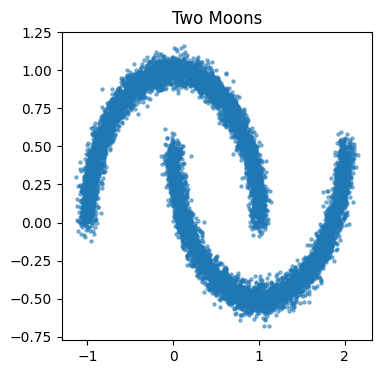

In [21]:
X_data, _ = make_moons(n_samples=10000, noise=0.05, random_state=2137)
X_data = torch.tensor(X_data, dtype=torch.float32)

plt.figure(figsize=(4, 4))
plt.scatter(X_data[:, 0], X_data[:, 1], s=5, alpha=0.5)
plt.title("Two Moons")
plt.show()

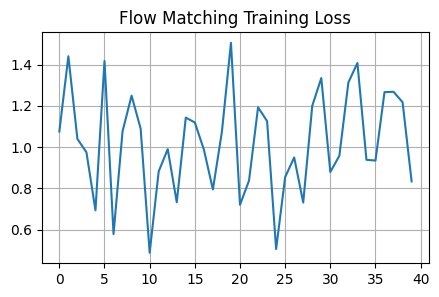

In [ ]:
v_net = VelocityNet().to(device)
fm_optimizer = optim.Adam(v_net.parameters(), lr=2e-3)
fm_history = []

EPOCHS = 40

v_net.train()
for epoch in range(EPOCHS): 
    # Tworzenie mini-paczek ręcznie
    permutation = torch.randperm(X_data.size(0))
    for i in range(0, X_data.size(0), 128):
        indices = permutation[i:i+128]
        x1 = X_data[indices].to(device)                     # Real data points
        x0 = torch.randn_like(x1).to(device)                # Gaussian noise
        
        # Próbkowanie losowego czasu t ~ U(0, 1) dla każdego punktu w paczce
        t = torch.rand(x1.size(0), 1).to(device)
        
        # Konstrukcja ścieżki interpolacji liniowej: x_t = (1 - t)*x_0 + t*x_1
        x_t = (1.0 - t) * x0 + t * x1
        
        # Docelowy wektor prędkości (Target velocity) dla ścieżki liniowej
        target_velocity = x1 - x0
        predicted_velocity = v_net(x_t, t)
        
        # Strata MSE między wektorami prędkości
        loss = F.mse_loss(predicted_velocity, target_velocity)
        
        fm_optimizer.zero_grad()
        loss.backward()
        fm_optimizer.step()
        
    fm_history.append(loss.item())

plt.figure(figsize=(5, 3))
plt.plot(fm_history)
plt.title("Flow Matching Training Loss")
plt.grid(True); plt.show()

In [ ]:
@torch.no_grad()
def sample_flow(model, n_samples=1000, n_steps=50, device="cpu"):
    model.eval()
    # Punkt startowy: losujemy czysty szum z rozkładu Gaussa
    x = torch.randn(n_samples, 2).to(device) 
    dt = 1.0 / n_steps

    # Integracja numeryczna równania różniczkowego (ODE) krok po kroku
    for step in range(n_steps):
        t_val = step * dt
        t = torch.full((n_samples, 1), t_val, dtype=torch.float32).to(device)
        
        # Sieć mówi nam, z jaką prędkością poruszają się punkty w tym momencie czasu
        v = model(x, t)
        
        # Aktualizacja pozycji: x = x + v * dt
        x = x + dt * v 
    return x.cpu()

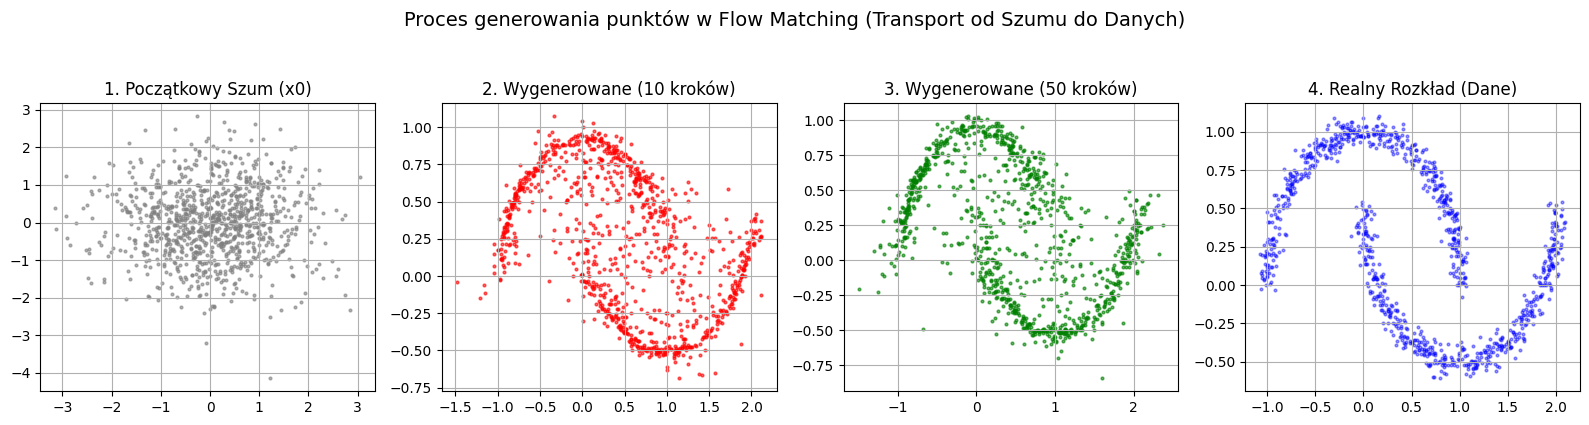

In [27]:
samples_10_steps = sample_flow(v_net, n_steps=10, device=device)
samples_50_steps = sample_flow(v_net, n_steps=50, device=device)
initial_noise = torch.randn(1000, 2)

# Rysowanie wykresów porównawczych (Wymóg sekcji Deliverables dla Task 2)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].scatter(initial_noise[:, 0], initial_noise[:, 1], s=4, color='gray', alpha=0.6)
axes[0].set_title("1. Początkowy Szum (x0)")
axes[0].grid(True)

axes[1].scatter(samples_10_steps[:, 0], samples_10_steps[:, 1], s=4, color='red', alpha=0.6)
axes[1].set_title("2. Wygenerowane (10 kroków)")
axes[1].grid(True)

axes[2].scatter(samples_50_steps[:, 0], samples_50_steps[:, 1], s=4, color='green', alpha=0.6)
axes[2].set_title("3. Wygenerowane (50 kroków)")
axes[2].grid(True)

axes[3].scatter(X_data[:1000, 0], X_data[:1000, 1], s=4, color='blue', alpha=0.4)
axes[3].set_title("4. Realny Rozkład (Dane)")
axes[3].grid(True)

plt.suptitle("Proces generowania punktów w Flow Matching (Transport od Szumu do Danych)", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

* **Input:** Sieć przyjmuje jako wejście wektor 3-wymiarowy: $[x_{t,1}, x_{t,2}, t] \in \mathbb{R}^3$. Składa się on z dwuwymiarowych współrzędnych przestrzennych punktu $x_t$ w danym momencie oraz czasu $t \in [0, 1]$.
* **Output:** Sieć zwraca wektor 2-wymiarowy $v_\theta(x_t, t) \in \mathbb{R}^2$, który reprezentuje predykcję pola wektorowego prędkości (wektor styczny/pochodną po czasie) w tym konkretnym miejscu i czasie.
* **Dlaczego prędkość docelowa to $x_1 - x_0$:** Ścieżka interpolacji liniowej to $x_t = (1 - t)x_0 + tx_1$. Aby znaleźć pole prędkości generujące ten ruch, liczymy pochodną $x_t$ po czasie $t$:

$$\frac{dx_t}{dt} = \frac{d}{dt} \big( x_0 - tx_0 + tx_1 \big) = x_1 - x_0$$



Ponieważ ścieżka między konkretnym punktem szumu a punktem danych jest linią prostą, docelowa prędkość jest stałym wektorem skierowanym bezpośrednio od szumu $x_0$ do celu $x_1$.
* **Dlaczego próbkowanie wymaga wielu małych kroków:** Choć pojedyncze trajektorie są liniami prostymi, to globalne pole prędkości wyuczone przez model (po uśrednieniu całego zbioru danych) jest silnie nieliniowe. Model zwraca lokalne wektory styczne. Aby płynnie zakrzywić trajektorie losowych punktów szumu i ułożyć je w skomplikowany kształt, musimy całkować to pole numerycznie za pomocą wielu małych kroków (np. metodą Eulera).
* **Co się dzieje, gdy liczba kroków jest zbyt mała:** Jeśli liczba kroków jest zbyt niska (np. $n\_steps = 10$), integracja numeryczna cierpi na duży błąd dyskretyzacji. Model nie potrafi odtworzyć ostrych granic oryginalnego zbioru danych.

* **Powiązanie z modelami dyfuzji:** Zarówno Flow Matching, jak i Modele Dyfuzyjne należą do ciągłych w czasie modeli generatywnych, których celem jest przekształcenie prostego szumu gaussowskiego w złożony rozkład danych. Klasyczna dyfuzja opiera się jednak na stochastycznych równaniach różniczkowych (SDE) z nieliniowymi i losowymi ścieżkami dodawania szumu, co spowalnia próbkowanie. Flow Matching upraszcza to, stosując deterministyczne równania różniczkowe zwyczajne (ODE) i proste ścieżki, co drastycznie przyspiesza generowanie próbek.

# Task 3

In [28]:
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

print(f"Ładowanie potoku na urządzenie: {device} z typem danych: {dtype}")

# 2. Inicjalizacja potoku z Hugging Face
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype
)
pipe = pipe.to(device)

# Wyłączenie filtrów bezpieczeństwa (opcjonalne, zapobiega zwracaniu czarnych obrazów dla niefortunnych seedów)
pipe.safety_checker = None

/Users/zoga/Studia-II/Neural-Networks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ładowanie potoku na urządzenie: mps z typem danych: torch.float32


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 10.82it/s]


In [ ]:
def generate_stable_diffusion(prompt, seed=42, num_steps=20):
    generator = torch.Generator(device=device).manual_seed(seed)
    
    output = pipe(
        prompt=prompt,
        num_inference_steps=num_steps,
        generator=generator
    )
    return output.images[0]

100%|██████████| 25/25 [01:16<00:00,  3.06s/it]


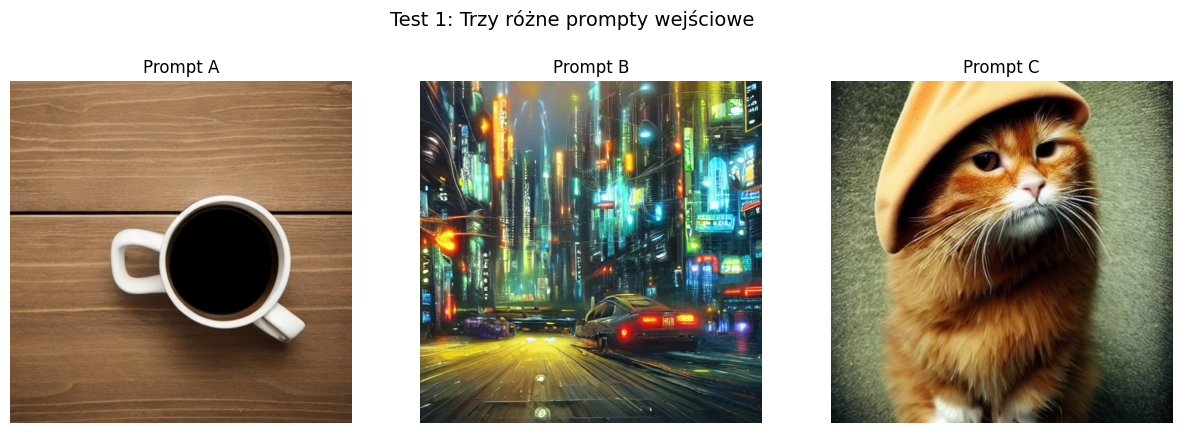

100%|██████████| 25/25 [01:17<00:00,  3.12s/it]


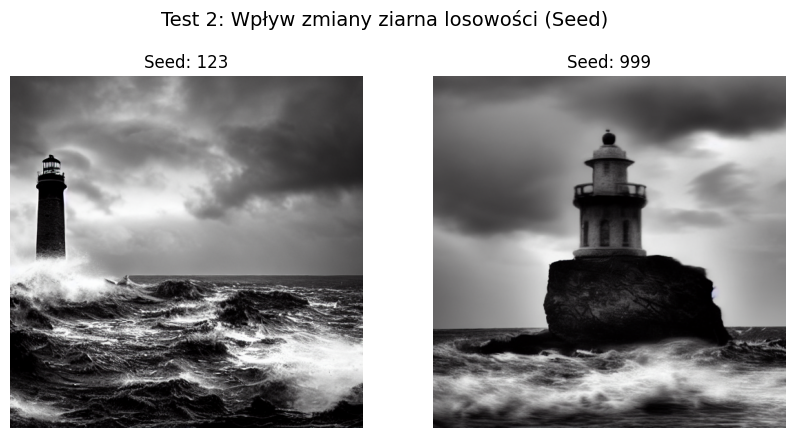

100%|██████████| 35/35 [01:42<00:00,  2.92s/it]


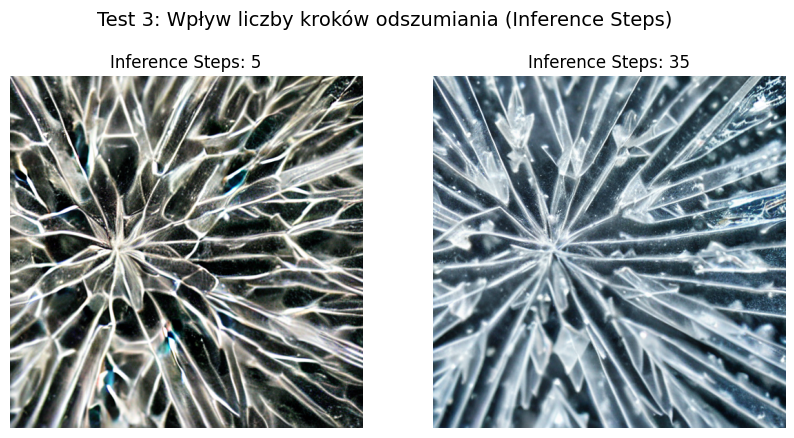

In [30]:
prompt_A = "A minimalist ceramic coffee mug on a clean wooden table, studio lighting, 4k"
prompt_B = "An oil painting of a futuristic cyberpunk city with flying cars, night time"
prompt_C = "A cute fluffy ginger cat wearing a tiny wizard hat, fantasy hyperrealistic"

img_A = generate_stable_diffusion(prompt_A, seed=42, num_steps=25)
img_B = generate_stable_diffusion(prompt_B, seed=42, num_steps=25)
img_C = generate_stable_diffusion(prompt_C, seed=42, num_steps=25)

# Wyświetlenie 3 różnych promptów
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_A); axes[0].set_title("Prompt A"); axes[0].axis('off')
axes[1].imshow(img_B); axes[1].set_title("Prompt B"); axes[1].axis('off')
axes[2].imshow(img_C); axes[2].set_title("Prompt C"); axes[2].axis('off')
plt.suptitle("Test 1: Trzy różne prompty wejściowe", fontsize=14)
plt.show()

# Stały prompt, zmiana random seed
prompt_fixed_seed = "A dramatic cinematic shot of an old stone lighthouse during a heavy sea storm"
img_seed_123 = generate_stable_diffusion(prompt_fixed_seed, seed=123, num_steps=25)
img_seed_999 = generate_stable_diffusion(prompt_fixed_seed, seed=999, num_steps=25)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_seed_123); axes[0].set_title("Seed: 123"); axes[0].axis('off')
axes[1].imshow(img_seed_999); axes[1].set_title("Seed: 999"); axes[1].axis('off')
plt.suptitle("Test 2: Wpływ zmiany ziarna losowości (Seed)", fontsize=14)
plt.show()

# Stały prompt, zmiana liczby kroków steps=5 vs steps=35
prompt_fixed_steps = "A detailed macro photograph of a sharp, crystal clear ice snowflake"
img_steps_5 = generate_stable_diffusion(prompt_fixed_steps, seed=42, num_steps=5)
img_steps_35 = generate_stable_diffusion(prompt_fixed_steps, seed=42, num_steps=35)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_steps_5); axes[0].set_title("Inference Steps: 5"); axes[0].axis('off')
axes[1].imshow(img_steps_35); axes[1].set_title("Inference Steps: 35"); axes[1].axis('off')
plt.suptitle("Test 3: Wpływ liczby kroków odszumiania (Inference Steps)", fontsize=14)
plt.show()

**1. Model Information**

* **Model:** `runwayml/stable-diffusion-v1-5`
* **Architektura:** Stable Diffusion 1.5 (Latent Diffusion Model)
* **Licencja:** CreativeML Open RAIL-M (otwarta licencja do celów akademickich i komercyjnych)

**2. Wpływ promptu (i negative promptu)**

* **Prompt:** Tekst steruje mechanizmem uwagi (Cross-Attention) w sieci UNet. Zmiana słów całkowicie zmienia generowany obiekt (np. zamienia kota w kubek).
* **Negative prompt:** Działa jak filtr – odpycha proces generowania od niechcianych elementów (np. usuwa rozmycie, brzydkie zniekształcenia czy dodatkowe palce).

**3. Wpływ ziarna losowości (Seed)**

* **Seed:** Definiuje wygląd początkowej, losowej macierzy szumu ($x_0$), z której startuje model.
* **Efekt:** Zmiana seeda przy tym samym tekście skutkuje stworzeniem zupełnie innej kompozycji i układu obiektów, ponieważ algorytm zaczyna odszumianie od innych wartości startowych.

**4. Wpływ liczby kroków (Inference Steps) oraz wartości CFG**

* **Liczba kroków:** Im większa tym lepszy wynik, ale nawet przy 5 obrzek wyszedł niezły.

* **CFG (Classifier-Free Guidance) Scale:** Decyduje, jak mocno model trzyma się tekstu. Niskie CFG ignoruje prompt, a zbyt wysokie (>15) sztucznie overfituje sie do tekstu.

$$\text{Ostateczny kierunek} = \text{Bez tekstu} + \text{CFG} \times (\text{Z tekstem} - \text{Bez tekstu})$$

**5. Dlaczego tylko inferencja?**

* **Powód:** Pełny trening Stable Diffusion od zera wymaga optymalizacji miliardów parametrów na wielkich klastrach superkomputerów przez tysiące godzin.